In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import re
import jieba

In [ ]:
# format: key is (english title, chinese douban title), 
# [english actor, chinese actor], 
# [top three actors, chinese translation of name], 

movies = {
    ('12 Angry Men','十二怒汉'): [
        ['Sidney Lumet', '西德尼·吕美特'],
        ['Henry Fonda', '亨利·方达', 'Lee J. Cobb', '李·J·科布', 'Ed Begley', '埃德·贝格利']
    ],
    ('2001: A Space Odyssey','2001太空漫游'): [
        ['Stanley Kubrick', '斯坦利·库布里克'],
        ['Keir Dullea', '基尔·杜利', 'Gary Lockwood', '加里·洛克伍德', 'William Sylvester', '威廉·西尔维斯特']
    ],
    ('A Beautiful Mind','美丽心灵'): [
        ['Ron Howard', '朗·霍华德'],
        ['Russell Crowe', '罗素·克劳', 'Jennifer Connelly', '詹妮弗·康纳利', 'Ed Harris', '艾德·哈里斯']
    ],
    ('Avatar','阿凡达'): [
        ['James Cameron', '詹姆斯·卡梅隆'],
        ['Sam Worthington', '萨姆·沃辛顿', 'Zoe Saldana', '佐伊·索尔达娜', 'Sigourney Weaver', '西格妮·韦弗']
    ],
    ('Black Swan','黑天鹅'): [
        ['Darren Aronofsky', '达伦·阿罗诺夫斯基'],
        ['Natalie Portman', '娜塔莉·波特曼', 'Mila Kunis', '米拉·库尼斯', 'Vincent Cassel', '文森特·卡索']
    ],
    ('Bohemian Rhapsody','波西米亚狂想曲'): [
        ['Bryan Singer', '布莱恩·辛格'],
        ['Rami Malek', '拉米·马雷克', 'Lucy Boynton', '露西·宝通', 'Gwilym Lee', '格威利姆·李']
    ],
    ('Catch Me If You Can','猫鼠游戏'): [
        ['Steven Spielberg', '史蒂文·斯皮尔伯格'],
        ['Leonardo DiCaprio', '莱昂纳多·迪卡普里奥', 'Tom Hanks', '汤姆·汉克斯', 'Christopher Walken', '克里斯托弗·沃肯']
    ],
    ('Coco','寻梦环游记'): [
        ['Lee Unkrich', '李·昂克里奇', 'Adrian Molina', '阿德里安·莫利纳'],
        ['Anthony Gonzalez', '安东尼·冈萨雷斯', 'Gael García Bernal', '盖尔·加西亚·贝纳尔', 'Benjamin Bratt', '本杰明·布拉特']
    ],
    ('Django Unchained','被解救的姜戈'): [
        ['Quentin Tarantino', '昆汀·塔伦蒂诺'],
        ['Jamie Foxx', '杰米·福克斯', 'Christoph Waltz', '克里斯托弗·瓦尔兹', 'Leonardo DiCaprio', '莱昂纳多·迪卡普里奥'],
    ],
    ('Fight Club','搏击俱乐部'): [
        ['David Fincher', '大卫·芬奇'],
        ['Brad Pitt', '布拉德·皮特', 'Edward Norton', '爱德华·诺顿', 'Helena Bonham Carter', '海伦娜·伯翰·卡特'],
    ],
    ('Forrest Gump','阿甘正传'): [
        ['Robert Zemeckis', '罗伯特·泽米吉斯'],
        ['Tom Hanks', '汤姆·汉克斯', 'Robin Wright', '罗宾·怀特', 'Gary Sinise', '加里·西尼斯']
    ],
    ('Frozen','冰雪奇缘'): [
        ['Chris Buck', '克里斯·巴克', 'Jennifer Lee', '詹妮弗·李'],
        ['Kristen Bell', '克里斯汀·贝尔', 'Idina Menzel', '伊迪娜·门泽尔', 'Jonathan Groff', '乔纳森·格罗夫']
    ],
    ('Gone Girl','消失的爱人'): [
        ['David Fincher', '大卫·芬奇'],
        ['Ben Affleck', '本·阿弗莱克', 'Rosamund Pike', '罗莎曼德·派克', 'Neil Patrick Harris', '尼尔·帕特里克·哈里斯']
    ],
    ('Good Will Hunting','心灵捕手'): [
        ['Gus Van Sant', '格斯·范·桑特'],
        ['Matt Damon', '马特·达蒙', 'Robin Williams', '罗宾·威廉姆斯', 'Ben Affleck', '本·阿弗莱克']
    ],
    ('Green Book','绿皮书'): [
        ['Peter Farrelly', '彼得·法雷里'],
        ['Viggo Mortensen', '维果·莫腾森', 'Mahershala Ali', '马赫沙拉·阿里', 'Linda Cardellini', '琳达·卡德里尼']
    ],
    ('Hacksaw Ridge','血战钢锯岭'): [
        ['Mel Gibson', '梅尔·吉布森'],
        ['Andrew Garfield', '安德鲁·加菲尔德', 'Sam Worthington', '萨姆·沃辛顿', 'Luke Bracey', '卢克·布雷西']
    ],
    ("Harry Potter and the Sorcerer's Stone",'哈利·波特与魔法石'): [
        ['Chris Columbus', '克里斯·哥伦布'],
        ['Daniel Radcliffe', '丹尼尔·雷德克里夫', 'Rupert Grint', '鲁伯特·格林特', 'Emma Watson', '艾玛·沃森']
    ],
    ('How to Train Your Dragon','驯龙高手'): [
        ['Dean DeBlois', '迪恩·德布洛斯', 'Chris Sanders', '克里斯·桑德斯'],
        ['Jay Baruchel', '杰伊·巴鲁切尔', 'Gerard Butler', '杰拉德·巴特勒', 'Craig Ferguson', '克雷格·费格森']
    ],
    ('Inception','盗梦空间'): [
        ['Christopher Nolan', '克里斯托弗·诺兰'],
        ['Leonardo DiCaprio', '莱昂纳多·迪卡普里奥', 'Marion Cotillard', '玛丽昂·歌迪亚', 'Tom Hardy', '汤姆·哈迪']
    ],
    ('Inglourious Basterds','无耻混蛋'): [
        ['Quentin Tarantino', '昆汀·塔伦蒂诺'],
        ['Brad Pitt', '布拉德·皮特', 'Christoph Waltz', '克里斯托弗·瓦尔兹', 'Mélanie Laurent', '梅拉尼·罗兰']
    ],
    ('Inside Out','头脑特工队'): [
        ['Pete Docter', '彼特·道格特', 'Ronnie Del Carmen', '罗纳尔多·德尔·卡门'],
        ['Amy Poehler', '艾米·波勒', 'Phyllis Smith', '菲莉丝·史密斯', 'Richard Kind', '理查德·坎德']
    ],
    ('Interstellar','星际穿越'): [
        ['Christopher Nolan', '克里斯托弗·诺兰'],
        ['Matthew McConaughey', '马修·麦康纳', 'Anne Hathaway', '安妮·海瑟薇', 'Jessica Chastain', '杰西卡·查斯坦']
    ],
    ('Joker','小丑'): [
        ['Todd Phillips', '托德·菲利普斯'],
        ['Joaquin Phoenix', '华金·菲尼克斯', 'Robert De Niro', '罗伯特·德尼罗', 'Zazie Beetz', '扎兹·比茨']
    ],
    
    ('La La Land','爱乐之城'): [
        ['Damien Chazelle', '达米恩·查泽雷'],
        ['Ryan Gosling', '瑞恩·高斯林', 'Emma Stone', '艾玛·斯通', 'John Legend', '约翰·传奇']
    ],
    ('Life Is Beautiful','美丽人生'): [
        ['Roberto Benigni', '罗伯托·贝尼尼'],
        ['Roberto Benigni', '罗伯托·贝尼尼', 'Nicoletta Braschi', '尼可莱塔·布拉斯基', 'Giorgio Cantarini', '乔治·坎塔里尼']
    ],
    ('Life of Pi','少年派的奇幻漂流'): [
        ['Ang Lee', '李安'],
        ['Suraj Sharma', '苏拉·沙玛', 'Irrfan Khan', '伊尔凡·可汗', 'Rafe Spall', '拉菲·斯波']
    ],
    ('Lock, Stock and Two Smoking Barrels','两杆大烟枪'): [
        ['Guy Ritchie', '盖·里奇'],
        ['Jason Flemyng', '杰森·弗莱明', 'Dexter Fletcher', '德克斯特·弗莱彻', 'Nick Moran', '尼克·莫兰']
    ],
    ('Léon: The Professional','这个杀手不太冷'): [
        ['Luc Besson', '吕克·贝松'],
        ['Jean Reno', '让·雷诺', 'Natalie Portman', '娜塔莉·波特曼', 'Gary Oldman', '加里·奥德曼']
    ],
    ('Mad Max: Fury Road','疯狂的麦克斯4：狂暴之路'): [
        ['George Miller', '乔治·米勒'],
        ['Tom Hardy', '汤姆·哈迪', 'Charlize Theron', '查理兹·塞隆', 'Nicholas Hoult', '尼古拉斯·霍尔特']
    ],
    ('Memento','记忆碎片'): [
        ['Christopher Nolan', '克里斯托弗·诺兰'],
        ['Guy Pearce', '盖·皮尔斯', 'Carrie-Anne Moss', '凯瑞-安·莫斯', 'Joe Pantoliano', '乔·潘托里亚诺']
    ],
    ('Monsters, Inc.','怪兽电力公司'): [
        ['Pete Docter', '彼特·道格特', 'David Silverman', '大卫·斯沃曼', 'Lee Unkrich', '李·昂克里奇'],
        ['John Goodman', '约翰·古德曼', 'Billy Crystal', '比利·克里斯托', 'Mary Gibbs', '玛丽·吉布斯']
    ],
    ("One Flew Over the Cuckoo's Nest",'飞越疯人院' ): [
        ['Miloš Forman', '米洛斯·福尔曼'],
        ['Jack Nicholson', '杰克·尼科尔森', 'Louise Fletcher', '路易丝·弗莱彻', 'Danny DeVito', '丹尼·德维托'] 
    ],
    ('Parasite','寄生虫'): [
        ['Bong Joon-ho', '奉俊昊'],
        ['Song Kang-ho', '宋康昊', 'Lee Sun-kyun', '李善均', 'Cho Yeo-jeong', '曹汝贞']
    ],
    ('Pirates of the Caribbean: The Curse of the Black Pearl','加勒比海盗'): [
        ['Gore Verbinski', '戈尔·维宾斯基'],
        ['Johnny Depp', '约翰尼·德普', 'Geoffrey Rush', '杰弗里·拉什', 'Orlando Bloom', '奥兰多·布鲁姆']
    ],
    ('Psycho','惊魂记'): [
        ['Alfred Hitchcock', '阿尔弗雷德·希区柯克'],
        ['Anthony Perkins', '安东尼·博金斯', 'Janet Leigh', '珍妮特·利', 'Vera Miles', '维拉·迈尔斯']
    ],
    ('Pulp Fiction','低俗小说'): [
        ['Quentin Tarantino', '昆汀·塔伦蒂诺'],
        ['John Travolta', '约翰·特拉沃尔塔', 'Samuel L. Jackson', '塞缪尔·杰克逊', 'Uma Thurman', '乌玛·瑟曼']
    ],
    ('Saving Private Ryan','拯救大兵瑞恩'): [
        ['Steven Spielberg', '史蒂文·斯皮尔伯格'],
        ['Tom Hanks', '汤姆·汉克斯', 'Matt Damon', '马特·达蒙', 'Tom Sizemore', '汤姆·塞兹摩尔']
    ],
    ("Schindler's List",'辛德勒的名单'): [
        ['Steven Spielberg', '史蒂文·斯皮尔伯格'],
        ['Liam Neeson', '连姆·尼森', 'Ben Kingsley', '本·金斯利', 'Ralph Fiennes', '拉尔夫·费因斯']
    ],
    ('Se7en','七宗罪'): [
        ['David Fincher', '大卫·芬奇'],
        ['Morgan Freeman', '摩根·弗里曼', 'Brad Pitt', '布拉德·皮特', 'Gwyneth Paltrow', '格温妮斯·帕特洛']
    ],
    ('Shutter Island','禁闭岛'): [
        ['Martin Scorsese', '马丁·斯科塞斯'],
        ['Leonardo DiCaprio', '莱昂纳多·迪卡普里奥', 'Mark Ruffalo', '马克·鲁法洛', 'Ben Kingsley', '本·金斯利']
    ],
    ('Slumdog Millionaire','贫民窟的百万富翁'): [
        ['Danny Boyle', '丹尼·博伊尔', 'Loveleen Tandan', '洛芙琳·坦丹'],
        ['Dev Patel', '戴夫·帕特尔', 'Freida Pinto', '芙蕾达·平托', 'Madhur Mittal', '麦活·米泰尔']
    ],
    ('Spider-Man: Into the Spider-Verse','蜘蛛侠：平行宇宙'): [
        ['Bob Persichetti', '鲍勃·佩尔西凯蒂', 'Peter Ramsey', '彼得·拉姆齐', 'Rodney Rothman', '罗德尼·罗斯曼'],
        ['Shameik Moore', '沙梅克·摩尔', 'Jake Johnson', '杰克·约翰逊', 'Hailee Steinfeld', '海莉·斯坦菲尔德']
    ],
    ('Spirited Away','千与千寻'): [
        ['Hayao Miyazaki', '宫崎骏'],
        ['Rumi Hiiragi', '柊瑠美', 'Miyu Irino', '入野自由', 'Mari Natsuki', '夏木真理']
    ],
    ('Terminator 2: Judgment Day','终结者2：审判日'): [
        ['James Cameron', '詹姆斯·卡梅隆'],
        ['Arnold Schwarzenegger', '阿诺·施瓦辛格', 'Linda Hamilton', '琳达·汉密尔顿', 'Edward Furlong', '爱德华·福隆']
    ],
    ('The Bourne Ultimatum','谍影重重3'): [
        ['Paul Greengrass', '保罗·格林格拉斯'],
        ['Matt Damon', '马特·达蒙', 'Julia Stiles', '朱莉娅·斯蒂尔斯', 'David Strathairn', '大卫·斯特雷泽恩']
    ],
    ('The Curious Case of Benjamin Button','本杰明·巴顿奇事'): [
        ['David Fincher', '大卫·芬奇'],
        ['Brad Pitt', '布拉德·皮特', 'Cate Blanchett', '凯特·布兰切特', 'Taraji P. Henson', '塔拉吉·P·汉森']
    ],
    ('The Dark Knight','蝙蝠侠：黑暗骑士'): [
        ['Christopher Nolan', '克里斯托弗·诺兰'],
        ['Christian Bale', '克里斯蒂安·贝尔', 'Heath Ledger', '希斯·莱杰', 'Aaron Eckhart', '艾伦·艾克哈特']
    ],
    ('The Godfather','教父'): [
        ['Francis Ford Coppola', '弗朗西斯·福特·科波拉'],
        ['Marlon Brando', '马龙·白兰度', 'Al Pacino', '阿尔·帕西诺', 'James Caan', '詹姆斯·肯恩']
    ],
    ('The Grand Budapest Hotel','布达佩斯大饭店'): [
        ['Wes Anderson', '韦斯·安德森'],
        ['Ralph Fiennes', '拉尔夫·费因斯', 'F. Murray Abraham', 'F·默里·亚伯拉罕', 'Mathieu Amalric', '马修·阿马立克']
    ],
    ('The Green Mile','绿里奇迹'): [
        ['Frank Darabont', '弗兰克·德拉邦特'],
        ['Tom Hanks', '汤姆·汉克斯', 'Michael Clarke Duncan', '迈克尔·克拉克·邓肯', 'David Morse', '大卫·摩斯']
    ],
    ('The Imitation Game','模仿游戏'): [
        ['Morten Tyldum', '莫滕·泰杜姆'],
        ['Benedict Cumberbatch', '本尼迪克特·康伯巴奇', 'Keira Knightley', '凯拉·奈特莉', 'Matthew Goode', '马修·古迪']
    ],
    ('The Intouchables','触不可及'): [
        ['Olivier Nakache', '奥利维埃·纳卡什', 'Éric Toledano', '埃里克·托莱达诺'],
        ['François Cluzet', '弗朗索瓦·克鲁塞', 'Omar Sy', '奥玛·希', 'Anne Le Ny', '安妮·勒尼']
    ],
    ('The Lion King','狮子王'): [
        ['Roger Allers', '罗杰·艾勒斯', 'Rob Minkoff', '罗伯·明可夫'],
        ['Matthew Broderick', '马修·布罗德里克', 'Jeremy Irons', '杰瑞米·艾恩斯', 'James Earl Jones', '詹姆斯·厄尔·琼斯']
    ],
    ('The Lord of the Rings: The Return of the King','指环王3：王者无敌'): [
        ['Peter Jackson', '彼得·杰克逊'],
        ['Elijah Wood', '伊利亚·伍德', 'Ian McKellen', '伊恩·麦克莱恩', 'Viggo Mortensen', '维果·莫腾森']
    ],
    ('The Martian','火星救援'): [
        ['Ridley Scott', '雷德利·斯科特'],
        ['Matt Damon', '马特·达蒙', 'Jessica Chastain', '杰西卡·查斯坦', 'Kristen Wiig', '克里斯汀·韦格']
    ],
    ('The Matrix','黑客帝国'): [
        ['Lana Wachowski', '拉娜·沃卓斯基', 'Lilly Wachowski', '莉莉·沃卓斯基'],
        ['Keanu Reeves', '基努·里维斯', 'Laurence Fishburne', '劳伦斯·菲什伯恩', 'Carrie-Anne Moss', '凯瑞-安·莫斯']
    ],
    ('The Notebook','恋恋笔记本'): [
        ['Nick Cassavetes', '尼克·卡萨维茨'],
        ['Ryan Gosling', '瑞恩·高斯林', 'Rachel McAdams', '瑞秋·麦克亚当斯', 'James Garner', '詹姆斯·加纳']
    ],
    ('The Pianist','钢琴家'): [
        ['Roman Polanski', '罗曼·波兰斯基'],
        ['Adrien Brody', '艾德里安·布洛迪', 'Thomas Kretschmann', '托马斯·克莱舒曼', 'Frank Finlay', '弗兰克·芬莱']
    ],
    ('The Prestige','致命魔术'): [
        ['Christopher Nolan', '克里斯托弗·诺兰'],
        ['Hugh Jackman', '休·杰克曼', 'Christian Bale', '克里斯蒂安·贝尔', 'Michael Caine', '迈克尔·凯恩']
    ],
    ('The Shawshank Redemption','肖申克的救赎'): [
        ['Frank Darabont', '弗兰克·德拉邦特'],
        ['Tim Robbins', '蒂姆·罗宾斯', 'Morgan Freeman', '摩根·弗里曼', 'Bob Gunton', '鲍勃·冈顿']
    ],
    ('The Silence of the Lambs','沉默的羔羊'): [
        ['Jonathan Demme', '乔纳森·德米'],
        ['Jodie Foster', '朱迪·福斯特', 'Anthony Hopkins', '安东尼·霍普金斯', 'Scott Glenn', '斯科特·格伦']
    ],
    ('The Sixth Sense','第六感'): [
        ['M. Night Shyamalan', 'M·奈特·沙马兰'],
        ['Bruce Willis', '布鲁斯·威利斯', 'Haley Joel Osment', '海利·乔·奥斯蒙', 'Toni Collette', '托妮·科莱特']
    ],
    ('The Truman Show','楚门的世界'): [
        ['Peter Weir', '彼得·威尔'],
        ['Jim Carrey', '金·凯瑞', 'Laura Linney', '劳拉·琳妮', 'Noah Emmerich', '诺亚·艾默里奇']
    ],
    ('Titanic','泰坦尼克号'): [
        ['James Cameron', '詹姆斯·卡梅隆'],
        ['Leonardo DiCaprio', '莱昂纳多·迪卡普里奥', 'Kate Winslet', '凯特·温丝莱特', 'Billy Zane', '比利·赞恩']
    ],
    ('Toy Story 3','玩具总动员3'): [
        ['Lee Unkrich', '李·昂克里奇'],
        ['Tom Hanks', '汤姆·汉克斯', 'Tim Allen', '蒂姆·艾伦', 'Joan Cusack', '琼·库萨克']
    ],
    ('Up','飞屋环游记'): [
        ['Pete Docter', '彼特·道格特', 'Bob Peterson', '鲍勃·彼德森'],
        ['Ed Asner', '艾德·阿斯纳', 'Christopher Plummer', '克里斯托弗·普卢默', 'Jordan Nagai', '长井章太']
    ],
    ('WALL·E','机器人总动员'): [
        ['Andrew Stanton', '安德鲁·斯坦顿'],
        ['Ben Burtt', '本·伯特', 'Elissa Knight', '艾丽莎·奈特', 'Jeff Garlin', '杰夫·格尔林']
    ],
    ('Whiplash','爆裂鼓手'): [
        ['Damien Chazelle', '达米恩·查泽雷'],
        ['Miles Teller', '迈尔斯·特勒', 'J.K. Simmons', 'J·K·西蒙斯', 'Paul Reiser', '保罗·赖泽']
    ]
}

In [61]:
# Load CSVs
df_cn = pd.read_csv('../douban_reviews.csv')

# Download English stopwords if needed
#nltk.download('stopwords')

#eng_stopwords = set(stopwords.words('english'))
eng_stopwords = set(open('../text_processing/custom_english_stopwords.txt', encoding='utf-8').read().split())
cn_stopwords = set(open('../text_processing/chinese_stopwords.txt', encoding='utf-8').read().split())


In [ ]:
# function of all of this is to get rid self mentions of titles, actors, and director
import re
import nltk
from nltk.corpus import stopwords
from fuzzywuzzy import fuzz
import string

# nltk.download('stopwords', quiet=True)

SPECIAL_TOKENS = {"<MOVIE_TITLE>", "<DIRECTOR_NAME>", "<ACTOR_NAME>"}
def normalize_bilingual(text):
    """Normalize Chinese-English text for matching:
    - Lowercases English letters
    - Removes all punctuation/symbols (both Chinese and Western)
    - Preserves Chinese characters, numbers, and whitespace
    """
    return re.sub(
        r"[^\w\s]",          # Match non-word/non-whitespace characters
        "", 
        text.lower(),        # Lowercase only affects English
        flags=re.UNICODE     # Ensure proper handling of Chinese characters
    )

def find_bilingual_title_mentions(text, title_tuple):
    """
    Find exact matches for Chinese titles in 《》 and English titles.
    """
    matches = []
    english_title, chinese_title = title_tuple

    # English title matching (case-insensitive, whole-word)
    if english_title and len(english_title) >= 2:
        en_pattern = r'\b' + re.escape(english_title) + r'\b'
        for match in re.finditer(en_pattern, text, flags=re.IGNORECASE):
            matches.append((match.start(), match.end(), "<MOVIE_TITLE>"))

    # Chinese title matching (exact substring or 《title》)
    if chinese_title and len(chinese_title) >= 2:
        # Match both bare title and 《title》
        patterns = [
            re.escape(chinese_title),          # Bare title: 阿甘正传
            re.escape(f"《{chinese_title}》")  # Bracketed: 《阿甘正传》
        ]
        
        for pattern in patterns:
            for match in re.finditer(pattern, text):
                matches.append((match.start(), match.end(), "<MOVIE_TITLE>"))

    return matches

def is_overlap(span, existing_spans):
    new_start, new_end = span
    for (exist_start, exist_end) in existing_spans:
        if (new_start < exist_end) and (new_end > exist_start):
            return True
    return False

def is_likely_general_name_reference(text, start, end):
    context_start = max(0, start - 40)
    context_end = min(len(text), end + 40)
    context = text[context_start:context_end].lower()

    positive_indicators = [
        'director', 'directed by', '主演', '主演者', '饰演', '表演', '扮演', '演员', '配音', '角色', '由', '参演', '出演',
        'star', 'performance', 'played by', 'cast', 'role', 'film', 'movie', 'drama', 'show', 'episode',
        'recommend', 'amazing', 'great', 'awesome', 'love', 'favorite', 'best', 'classic', 'iconic', 'legendary',
        'yyds', '安利', '吹爆', '神仙', '教科书级', '彩蛋', '二刷', '哭死', '破防', '小姐姐', '小哥哥'
    ]

    # Generalized negative indicators (common function words, negations, and question words)
    negative_indicators = [
        'the', 'a', 'an', 'is', 'was', 'were', 'are', 'his', 'her', 'its', 'their', 'this', 'that',
        '了', '的', '在', '和', '这', '那', '他', '她', '它', '怎样', '怎么', '为什么', '居然', '真的', '不要', '吗', '吧', '啊',
        '！', '？', '～', '不是', '没', '没有', '别', '无', '非'
    ]

        # Check positive indicators
    if any(indicator in context for indicator in positive_indicators):
        return True

        # Check negative indicators before the match
    word_before = text[max(0, start-10):start].strip().split()
    if word_before and word_before[-1].lower() in negative_indicators:
        return False

    return True

def find_bilingual_name_mentions(text, names_list):
    """
    Enhanced bilingual name matcher that:
    - Matches full names directly
    - Matches first/last names with context validation
    - Handles possessive forms and Chinese names
    """
    matches = []
    seen_spans = set()
    # Sort by English name length first, then Chinese
    sorted_names = sorted(
        names_list,
        key=lambda x: (-len(x[0]), -len(x[1])) if x[0] else (-len(x[1]),)
    )
    
    for en_name, zh_name, tag in sorted_names:
        # --- English Name Matching ---
        if en_name:
            name_parts = en_name.split()
            
            # 1. Full name match (no context check needed)
            full_pattern = re.compile(rf'\b{re.escape(en_name)}\b', re.IGNORECASE)
            for m in full_pattern.finditer(text):
                span = (m.start(), m.end())
                if not is_overlap(span, seen_spans):
                    matches.append((*span, tag))
                    seen_spans.add(span)
            
            # 2. First and last name components with context check
            if len(name_parts) >= 2:
                first_part = name_parts[0]
                last_part = name_parts[-1]

                # Match first name (e.g. "Tom" from "Tom Hanks")
                first_pattern = re.compile(rf'\b{re.escape(first_part)}\b', re.IGNORECASE)
                for m in first_pattern.finditer(text):
                    span = (m.start(), m.end())
                    if not is_overlap(span, seen_spans):
                        if is_likely_general_name_reference(text, span[0], span[1]):
                            matches.append((*span, tag))
                            seen_spans.add(span)
                
                # Match last name (e.g. "Hanks" from "Tom Hanks")
                last_pattern = re.compile(rf'\b{re.escape(last_part)}\b', re.IGNORECASE)
                for m in last_pattern.finditer(text):
                    span = (m.start(), m.end())
                    if not is_overlap(span, seen_spans):
                        if is_likely_general_name_reference(text, span[0], span[1]):
                            matches.append((*span, tag))
                            seen_spans.add(span)
            
            # 3. Possessive forms (e.g. "Hanks'")
            if len(name_parts) >= 1:
                last_part = name_parts[-1]
                possessive_pattern = re.compile(rf'\b{re.escape(last_part)}\'s?\b', re.IGNORECASE)
                for m in possessive_pattern.finditer(text):
                    span = (m.start(), m.end())
                    if not is_overlap(span, seen_spans):
                        if is_likely_general_name_reference(text, span[0], span[1]):
                            matches.append((*span, tag))
                            seen_spans.add(span)

        # --- Chinese Name Matching ---
        if zh_name and len(zh_name) >= 2:
            # Full name match
            idx = text.find(zh_name)
            while idx != -1:
                span = (idx, idx + len(zh_name))
                if not is_overlap(span, seen_spans):
                    matches.append((*span, tag))
                    seen_spans.add(span)
                idx = text.find(zh_name, idx + 1)
            
            # Component matches (e.g. 迪卡普里奥 from 莱昂纳多·迪卡普里奥)
            components = zh_name.split('·')
            for component in components:
                for m in re.finditer(re.escape(component), text):
                    span = (m.start(), m.end())
                    if not is_overlap(span, seen_spans):
                        if is_likely_general_name_reference(text, span[0], span[1]):
                            matches.append((*span, tag))
                            seen_spans.add(span)

    return matches

def is_common_word_with_s(word):
    """Check if a word is a common English word that might end with 's."""
    common_words = {
        'his', 'hers', 'its', 'theirs', 'ours', 'yours', 'this', 'that',
        'was', 'has', 'does', 'goes', 'comes', 'makes', 'takes', 'gives',
        'seems', 'looks', 'feels', 'sounds', 'appears', 'becomes'
    }
    return word.lower() in common_words

def get_common_words():
    """Get a set of common English words to avoid matching."""
    return {
        'the', 'be', 'to', 'of', 'and', 'a', 'in', 'that', 'have', 'it',
        'for', 'not', 'on', 'with', 'he', 'as', 'you', 'do', 'at', 'this',
        'but', 'his', 'by', 'from', 'they', 'we', 'say', 'her', 'she', 'or',
        'an', 'will', 'my', 'one', 'all', 'would', 'there', 'their', 'what',
        'so', 'up', 'out', 'if', 'about', 'who', 'get', 'which', 'go', 'me',
        'when', 'make', 'can', 'like', 'time', 'no', 'just', 'him', 'know',
        'take', 'people', 'into', 'year', 'your', 'good', 'some', 'could',
        'them', 'see', 'other', 'than', 'then', 'now', 'look', 'only', 'come',
        'its', 'over', 'think', 'also', 'back', 'after', 'use', 'two', 'how',
        'our', 'work', 'first', 'well', 'way', 'even', 'new', 'want', 'because',
        'any', 'these', 'give', 'day', 'most', 'us', 'still', 'find', 'tell',
        'really', 'dark', 'great', 'movie', 'film', 'scene', 'character', 'story',
        'plot', 'director', 'actor', 'actress', 'hero', 'villain', 'killer',
        'murder', 'death', 'child', 'mind', 'moral', 'figure', 'foundation'
    }

 # 2. Prepare director/actor entries
def prepare_entities(raw_list, tag):
    """Convert [en1, zh1, en2, zh2...] to [(en1, zh1, tag), (en2, zh2, tag)...]"""
    entities = []
    for i in range(0, len(raw_list), 2):
        en = raw_list[i] if i < len(raw_list) else ""
        zh = raw_list[i+1] if (i+1) < len(raw_list) else ""
        entities.append((en, zh, tag))
    return entities

def preprocess_movie_review(text, movies, title_tuple):
    """
    Bilingual movie review preprocessor that handles both Chinese and English text.
    - movies: Dictionary where keys are (english_title, chinese_title) tuples
    - values: [directors, actors] where:
      directors = [en_name1, zh_name1, en_name2, zh_name2...]
      actors = [en_name1, zh_name1, en_name2, zh_name2...]
    """
    # Basic preprocessing if movie not in dictionary
    if title_tuple not in movies:
        text_normalized = normalize_bilingual(text)
        words = text_normalized.split()
        stops = eng_stopwords
        cleaned = [w for w in words if w not in eng_stopwords and w not in cn_stopwords]
        return " ".join(cleaned)

    directors, actors = movies[title_tuple]

    # Find all entity matches
    entity_matches = []
    
    # 1. Find movie title mentions (both English and Chinese)
    entity_matches.extend(find_bilingual_title_mentions(text, title_tuple))
    
    # 3. Find director and actor mentions
    director_entries = prepare_entities(directors, "<DIRECTOR_NAME>")
    actor_entries = prepare_entities(actors, "<ACTOR_NAME>")
    
    entity_matches.extend(find_bilingual_name_mentions(text, director_entries))
    entity_matches.extend(find_bilingual_name_mentions(text, actor_entries))

    # 4. Remove overlapping matches (prioritize longer spans)
    entity_matches.sort(key=lambda x: (x[0], -x[1]))  # Sort by start pos then negative length
    filtered_matches = []
    prev_end = -1
    for start, end, tag in entity_matches:
        if start >= prev_end:
            filtered_matches.append((start, end, tag))
            prev_end = end

    # 5. Replace entities in text (reverse order to preserve indices)
    text_processed = text
    for start, end, tag in reversed(filtered_matches):
        text_processed = text_processed[:start] + tag + text_processed[end:]

    # 6. Clean text while preserving special tokens
    text_processed = text_processed.lower()
    
    # Preserve special tokens during punctuation removal
    for token in SPECIAL_TOKENS:
        text_processed = text_processed.replace(token.lower(), f" {token} ")
    
    # Remove non-special punctuation
    text_processed = re.sub(r"[^\w\s<>]", " ", text_processed)
    
    words = text_processed.split()
    # Updated stopword check for both languages
    cleaned = [w for w in words if (w in SPECIAL_TOKENS) or (w not in eng_stopwords and w not in cn_stopwords)]
    
    return " ".join(cleaned)

In [96]:
en_to_cn = {en: cn for (en, cn) in movies.keys()}

In [97]:
df_cn['processed_comment'] = df_cn.apply(
    lambda row: preprocess_movie_review(
        row['review_text'], 
        movies, 
        (row['title'], en_to_cn.get(row['title'], None))  # Pass the tuple
    ),
    axis=1
)

In [99]:
df_cn.iloc[100]['processed_comment']


'此影评完全不包含剧透 几乎每一个看过 <MOVIE_TITLE> 的都会对他由衷喜欢 有的能给出列出各种原因 希望 成长 爱情 生活 配乐 演技 电影中人物的经历 成长 对话几乎没有一处不让你感动在看电影的时候仿若置身其境 感动 唏嘘 激动 兴奋 狂喜 泪目 但我看过此片后 却没有产生一丝感觉 而且在我第一次看这部电影的时候 竟然觉得无聊至极瞌睡连连 差点睡着 而且看完之后电影内容也没有给我留下一丝印象 当时我失望至极 没想到一不受到如此追捧 评价人数多 评价分数高 豆瓣评分人数超过六十万评分超过九分 在豆瓣和imdv都是都是霸占着top榜单前十 而且与 三傻 肖申克的救赎 等电影齐名并且内容也类似 给我带来的直接感觉竟然是如此天差地别 前二者我在观影的过程中热血捧场兴奋异常观影感受就如喜欢 <MOVIE_TITLE> 的人看 <MOVIE_TITLE> 的感受 视为心中经典 百看不厌 为了不误解一部可能好电影我还后来的几年时间没又反反复把这部电影重新看过好几遍 却从来是跟最开始的感受一模一样完全没有变化 勉强能说的上来的得到的不能的发现就是 1配乐确实不错 音乐响起的时间把握得非常好 2 可能电影从某种程度上客观地展现了美国一些特殊的时期的历史缩影 一个白痴 最后也只能找到一个黑木耳 一个女人 百般放纵玩累了过后就不会太所谓对方的条件 要的只是一个依靠 一个安稳 真正心甘情愿无怨无悔愿意一直等着你的人 大概也只有白痴了 它带给我的感受还是如此平淡 如此一般 如此冗长 如此无聊 我说这些话并无恶意 因为我知道 我也确实看到 有一部分人 尽管相对而言是极少一部分人 包括我 对这部电影打了一星过两星或者不明觉厉人云亦云没有主见的单纯地因为别人都说好而打了高分 我只是意在说出这些人的真实感受 对于那些和我一样因为电影不能自己找到一丝观影的愉悦感打低分的人 完全赞同楼主评价一部电影 不仅是 <MOVIE_TITLE> 的态度 此之蜜糖此之砒霜 每部作品都有他的优点了缺点 也都会有人喜欢有人讨厌 更何况观影更是一件主观的事 别人喜欢 是别人的口味 是别人的自有 我不喜欢 自然有我的愿意 我讨厌吃糖再多的人说喜欢也不能改变我 认识并且承认自己的口味 着重自己的个性和特点才是着重自己 而且从某个角度来 这又何尝不是对一部作品 电影评价 本身的尊重 我们对 <MOVIE_TITL

In [8]:
#load in custom stopwords
custom_stopwords = set(open('../text_processing/custom_english_stopwords.txt', encoding='utf-8').read().split())
words = []
for word in custom_stopwords:
    word = word.lower()
    words.append(word)
custom_stopwords = set(words)

In [9]:
# English preprocessing
def clean_english(text):
    text = str(text).lower()
    words = [w for w in text.split() if w not in custom_stopwords]
    return ' '.join(words)

# Apply preprocessing
df_en['clean_comment'] = df_en['processed_comment'].apply(clean_english)

In [10]:
comments = df_en["clean_comment"].dropna().tolist()

In [11]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")

embeddings = model.encode(comments, show_progress_bar=True)

/Users/crystalpeng/ds-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 241/241 [02:10<00:00,  1.84it/s]


In [12]:
#do clustering
from sklearn.cluster import KMeans

num_clusters = 10 # tweak this
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)

df_en['cluster'] = labels

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [13]:
df_en['cluster'].value_counts()

cluster
5    1310
4    1146
2    1053
8    1031
0     788
6     653
3     547
1     495
7     395
9     289
Name: count, dtype: int64

In [14]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from keybert import KeyBERT
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

def extract_keybert_keywords(df_en, model, num_keywords=10):
    print("=== KEYBERT KEYWORDS ===\n")
    kw_model = KeyBERT(model)
    for i in range(num_clusters):
        cluster_comments = df_en[df_en['cluster'] == i]['clean_comment'].tolist()
        joined = " ".join(cluster_comments)
        keywords = kw_model.extract_keywords(joined, top_n=num_keywords)
        print(f"Cluster {i} keywords:", keywords)

def analyze_clusters_comprehensive(df_en, text_column='processed_comment'):
    """
    Comprehensive cluster analysis with multiple methods
    """
    
    # 1. TF-IDF Based Analysis (most discriminative terms per cluster)
    print("=== TF-IDF DISCRIMINATIVE TERMS ===\n")
    
    # Create a document for each cluster by joining all comments
    cluster_docs = []
    for i in range(df_en['cluster'].nunique()):
        cluster_text = ' '.join(df_en[df_en['cluster'] == i][text_column].tolist())
        cluster_docs.append(cluster_text)
    
    # Compute TF-IDF
    tfidf = TfidfVectorizer(max_features=100, ngram_range=(1, 3), stop_words='english')
    tfidf_matrix = tfidf.fit_transform(cluster_docs)
    feature_names = tfidf.get_feature_names_out()
    
    # Get top terms for each cluster based on TF-IDF scores
    for i in range(len(cluster_docs)):
        scores = tfidf_matrix[i].toarray().flatten()
        top_indices = scores.argsort()[-15:][::-1]  # Top 15 terms
        top_terms = [(feature_names[idx], scores[idx]) for idx in top_indices]
        
        print(f"Cluster {i} - Most Discriminative Terms:")
        for term, score in top_terms[:10]:
            print(f"  {term}: {score:.3f}")
        print()
    
    # 3. Movie and Rating Distribution
    print("\n=== MOVIE & RATING DISTRIBUTION ===\n")
    
    for i in range(df_en['cluster'].nunique()):
        cluster_df = df_en[df_en['cluster'] == i]
        
        print(f"Cluster {i}:")
        print(f"  Size: {len(cluster_df)} reviews")
        
        # Top movies in this cluster
        top_movies = cluster_df['title'].value_counts().head(5)
        print(f"  Top movies:")
        for movie, count in top_movies.items():
            print(f"    - {movie}: {count} reviews")
        
        # Rating distribution if available
        if 'rating' in df_en.columns:
            print(f"  Average rating: {cluster_df['rating'].mean():.2f}")
            print(f"  Rating std: {cluster_df['rating'].std():.2f}")
        
        print()

    # 5. Length Analysis
    print("\n=== REVIEW LENGTH ANALYSIS ===\n")
    
    df_en['review_length'] = df_en[text_column].str.split().str.len()
    
    for i in range(df_en['cluster'].nunique()):
        cluster_lengths = df_en[df_en['cluster'] == i]['review_length']
        print(f"Cluster {i}:")
        print(f"  Average length: {cluster_lengths.mean():.1f} words")
        print(f"  Median length: {cluster_lengths.median():.1f} words")
        print()
    
    # 4. Special Token Analysis
    print("\n=== SPECIAL TOKEN USAGE ===\n")
    
    special_tokens = [ 'director_name', 'actor_name']
    
    for i in range(df_en['cluster'].nunique()):
        cluster_comments = df_en[df_en['cluster'] == i][text_column].tolist()
        all_text = ' '.join(cluster_comments)
        
        print(f"Cluster {i}:")
        for token in special_tokens:
            count = all_text.count(token)
            avg_per_review = count / len(cluster_comments)
            print(f"  {token}: {count} total ({avg_per_review:.2f} per review)")
        print()

def get_sample_reviews(df_en, n_samples=3):
#print some random comments from each cluster
    """
    Get representative reviews from each cluster
    """
    print("\n=== RANDOM SAMPLE REVIEWS ===\n")
    
    for cluster_num in sorted(df_en['cluster'].unique()):
        print(f"\nCluster {cluster_num}:")
        sample_comments = df_en[df_en['cluster'] == cluster_num]['comment'].sample(n_samples, random_state=42)
        for comment in sample_comments:
            print(" -", comment)
            print()
        print("-" * 40)

def extract_unique_ngrams(df_en, text_column='processed_comment'):
    """
    Find n-grams that are unique or highly specific to each cluster
    """
    print("\n=== UNIQUE N-GRAMS PER CLUSTER ===\n")
    
    from sklearn.feature_extraction.text import CountVectorizer
    
    # Get n-grams for each cluster
    cluster_ngrams = {}
    
    for i in range(df_en['cluster'].nunique()):
        cluster_text = df_en[df_en['cluster'] == i][text_column].tolist()
        
        # Extract bigrams and trigrams
        vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=100)
        try:
            ngram_counts = vectorizer.fit_transform(cluster_text)
            feature_names = vectorizer.get_feature_names_out()
            
            # Sum occurrences across all documents in cluster
            total_counts = ngram_counts.sum(axis=0).A1
            ngram_freq = list(zip(feature_names, total_counts))
            ngram_freq.sort(key=lambda x: x[1], reverse=True)
            
            cluster_ngrams[i] = dict(ngram_freq[:20])  # Top 20 n-grams
        except:
            cluster_ngrams[i] = {}
    
    # Find n-grams unique to each cluster
    for i in range(df_en['cluster'].nunique()):
        print(f"Cluster {i} - Unique/Distinctive N-grams:")
        
        current_ngrams = set(cluster_ngrams[i].keys())
        other_ngrams = set()
        
        for j in range(df_en['cluster'].nunique()):
            if j != i:
                other_ngrams.update(cluster_ngrams[j].keys())
        
        unique_ngrams = current_ngrams - other_ngrams
        
        if unique_ngrams:
            for ngram in list(unique_ngrams)[:10]:
                print(f"  - {ngram}: {cluster_ngrams[i][ngram]} occurrences")
        else:
            # If no unique n-grams, show most frequent
            for ngram, count in list(cluster_ngrams[i].items())[:5]:
                print(f"  - {ngram}: {count} occurrences")
        print()

def visualize_clusters(df_en, embeddings):
    """
    Visualize clusters using dimensionality reduction
    """
    # PCA visualization
    pca = PCA(n_components=2)
    pca_coords = pca.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], 
                         c=df_en['cluster'], cmap='tab10', alpha=0.6)
    plt.colorbar(scatter)
    plt.title('Clusters in PCA Space')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    
    # t-SNE visualization (for smaller datasets)
    if len(df_en) < 5000:  # t-SNE is computationally expensive
        tsne = TSNE(n_components=2, random_state=42)
        tsne_coords = tsne.fit_transform(embeddings)
        
        plt.subplot(1, 2, 2)
        scatter = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], 
                             c=df_en['cluster'], cmap='tab10', alpha=0.6)
        plt.colorbar(scatter)
        plt.title('Clusters in t-SNE Space')
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
    
    plt.tight_layout()
    plt.show()

def visualize_clusters2(df_en, embeddings):
    """
    Visualize clusters using dimensionality reduction but different output
    """
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)

    df_en['x'] = reduced[:, 0]
    df_en['y'] = reduced[:, 1]

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_en, x='x', y='y', hue='cluster', palette='tab10')
    plt.title("IMDB Comment Clusters")
    plt.show()

def analyze_cluster_themes(df_en, text_column='processed_comment'):
    """
    High-level theme analysis based on semantic patterns
    """
    print("\n=== POTENTIAL CLUSTER THEMES ===\n")
    
    # Define theme indicators
    theme_patterns = {
        'Technical/Cinematography': ['cinematography', 'camera', 'shot', 'visual', 'effects', 'lighting', 'score', 'soundtrack'],
        'Plot/Story': ['plot', 'story', 'narrative', 'ending', 'twist', 'predictable', 'boring', 'confusing'],
        'Acting/Performance': ['<ACTOR_NAME>', 'actor_name', 'acting', 'performance', 'character', 'role', 'cast'],
        'Direction': ['<DIRECTOR_NAME>', 'director_name', 'direction', 'directed', 'filmmaker'],
        'Genre-specific': ['horror', 'comedy', 'thriller', 'drama', 'action', 'romantic'],
        'Emotional Response': ['love', 'hate', 'disappoint', 'amazing', 'terrible', 'worst', 'best', 'masterpiece'],
        'Critical/Analytical': ['overrated', 'underrated', 'critic', 'review', 'analysis', 'interpret'],
    }
    
    for i in range(df_en['cluster'].nunique()):
        cluster_text = ' '.join(df_en[df_en['cluster'] == i][text_column].tolist()).lower()
        
        print(f"\nCluster {i} - Theme Scores:")
        theme_scores = {}
        
        for theme, keywords in theme_patterns.items():
            score = sum(cluster_text.count(keyword.lower()) for keyword in keywords)
            theme_scores[theme] = score
        
        # Normalize by cluster size
        cluster_size = len(df_en[df_en['cluster'] == i])
        
        # Sort themes by score
        sorted_themes = sorted(theme_scores.items(), key=lambda x: x[1], reverse=True)
        
        for theme, score in sorted_themes[:5]:
            normalized_score = score / cluster_size
            print(f"  {theme}: {normalized_score:.2f} mentions per review")


In [15]:
extract_keybert_keywords(df_en, model, num_keywords=10)

=== KEYBERT KEYWORDS ===

Cluster 0 keywords: [('scenes', 0.4348), ('critics', 0.4269), ('brokeback', 0.4173), ('sicario', 0.4062), ('comedies', 0.4024), ('screenwriting', 0.3997), ('cast', 0.395), ('screenwriters', 0.3943), ('actors', 0.3878), ('blackkklansman', 0.3819)]
Cluster 1 keywords: [('cartoons', 0.3661), ('dialogues', 0.3619), ('clichés', 0.361), ('cliches', 0.361), ('ideas', 0.3588), ('cartoonesque', 0.3543), ('cartoonish', 0.3517), ('cartoony', 0.3509), ('words', 0.3494), ('clichéd', 0.3453)]
Cluster 2 keywords: [('comedies', 0.4585), ('thrillers', 0.4525), ('tropes', 0.4396), ('dramas', 0.4195), ('portrayals', 0.4105), ('scripts', 0.4104), ('comedy', 0.4096), ('hollywoodisms', 0.4084), ('novels', 0.4074), ('anachronisms', 0.4048)]
Cluster 3 keywords: [('thrillers', 0.433), ('letdowns', 0.4212), ('mediocrity', 0.4077), ('comedies', 0.3958), ('mediocre', 0.3946), ('dramas', 0.391), ('thriller', 0.3882), ('critics', 0.3803), ('endings', 0.3799), ('storylines', 0.3789)]
Cluste

=== TF-IDF DISCRIMINATIVE TERMS ===

Cluster 0 - Most Discriminative Terms:
  actor_name: 0.708
  best: 0.238
  people: 0.190
  great: 0.165
  acting: 0.155
  director_name: 0.149
  character: 0.141
  bad: 0.131
  better: 0.127
  love: 0.104

Cluster 1 - Most Discriminative Terms:
  characters: 0.369
  people: 0.232
  plot: 0.206
  character: 0.203
  didn: 0.183
  little: 0.183
  old: 0.180
  love: 0.169
  better: 0.169
  thing: 0.147

Cluster 2 - Most Discriminative Terms:
  actor_name: 0.337
  people: 0.266
  plot: 0.242
  character: 0.228
  end: 0.220
  characters: 0.191
  love: 0.167
  didn: 0.159
  going: 0.149
  bad: 0.134

Cluster 3 - Most Discriminative Terms:
  boring: 0.613
  people: 0.233
  plot: 0.220
  didn: 0.195
  bad: 0.187
  minutes: 0.173
  waste: 0.143
  long: 0.143
  characters: 0.139
  watched: 0.133

Cluster 4 - Most Discriminative Terms:
  people: 0.238
  actor_name: 0.235
  plot: 0.232
  bad: 0.221
  great: 0.214
  didn: 0.204
  acting: 0.184
  10: 0.179
  bette

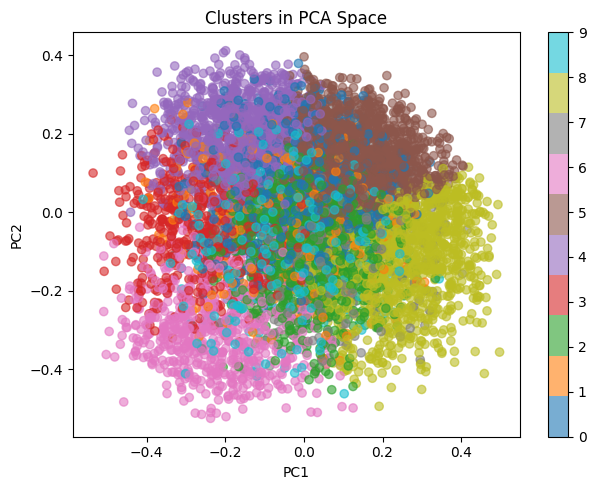

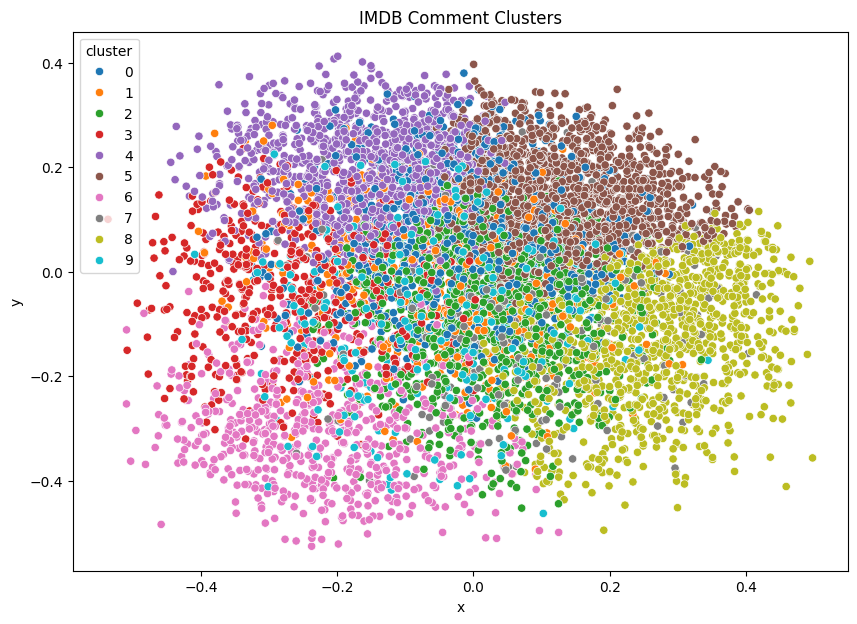

In [16]:
# Run comprehensive analysis
analyze_clusters_comprehensive(df_en, text_column='clean_comment')

# Extract unique n-grams
extract_unique_ngrams(df_en, text_column='processed_comment')

# Analyze themes
analyze_cluster_themes(df_en, text_column='processed_comment')

#get random reviews
get_sample_reviews(df_en, n_samples=3)

# If you have embeddings available
visualize_clusters(df_en, embeddings)
visualize_clusters2(df_en, embeddings)

In [128]:
def print_cluster_table(df):
    # Build the pivot table
    table = df[['title', 'cluster']].value_counts().unstack(fill_value=0)
  
    # Convert floats to ints if needed
    table = table.astype(int)

    # Print each row cleanly
    print("Title".ljust(40), end="")
    for col in table.columns:
        print(f"Cluster {col}".rjust(12), end="")
    print()

    print("-" * (40 + 12 * len(table.columns)))
    
    for title, row in table.iterrows():
        print(title.ljust(40), end="")
        for count in row:
            print(str(count).rjust(12), end="")
        print()

In [129]:
print_cluster_table(df_en)

Title                                      Cluster 0   Cluster 1   Cluster 2   Cluster 3   Cluster 4   Cluster 5   Cluster 6   Cluster 7   Cluster 8   Cluster 9
----------------------------------------------------------------------------------------------------------------------------------------------------------------
12 Angry Men                                       4           2           0           0           4           3           5           0           3           4
2001: A Space Odyssey                              3          36           0          14          12          38          18           2          32          45
A Beautiful Mind                                  33           5           1           2          11           2          20           0           2          19
Avatar                                             3          27           4          12           9          13          10          10          47          64
Black Swan                        

In [130]:
table = df_en[['title', 'cluster']].value_counts().unstack()
table.loc